Train size: 2573, Test size: 644

HAR-RV model summary:
                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     41.82
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           2.23e-26
Time:                        13:52:38   Log-Likelihood:                -5808.1
No. Observations:                2573   AIC:                         1.162e+04
Df Residuals:                    2569   BIC:                         1.165e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

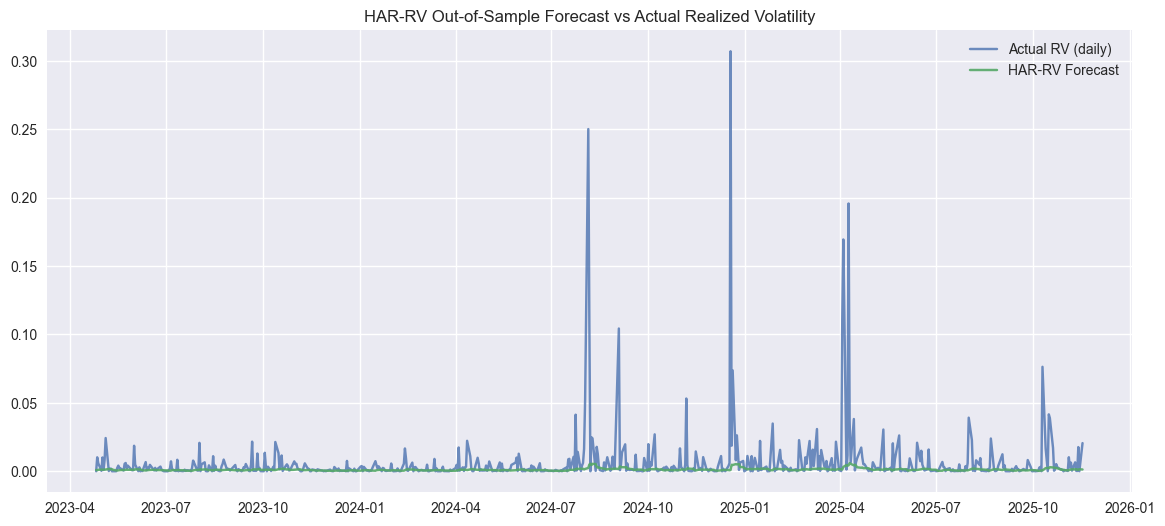


HAR-RV Forecast Performance on Test Set:
MSE: 4.642263e-04
MAE: 5.746847e-03


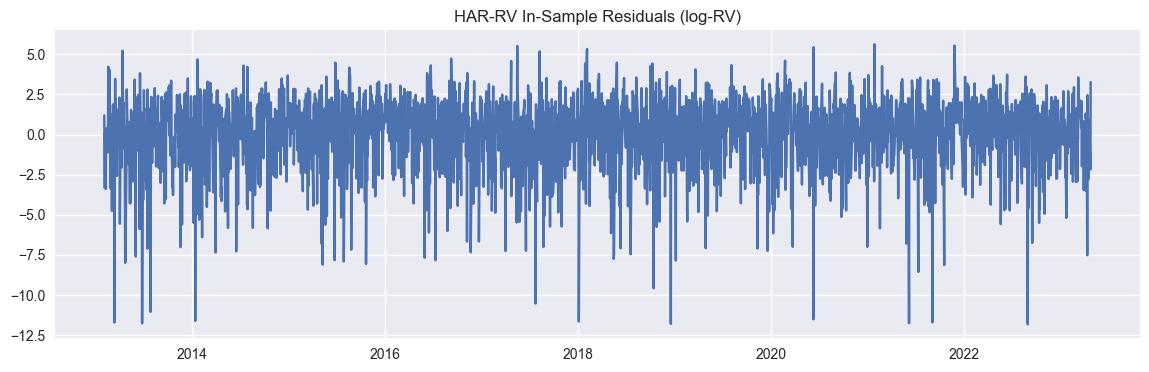

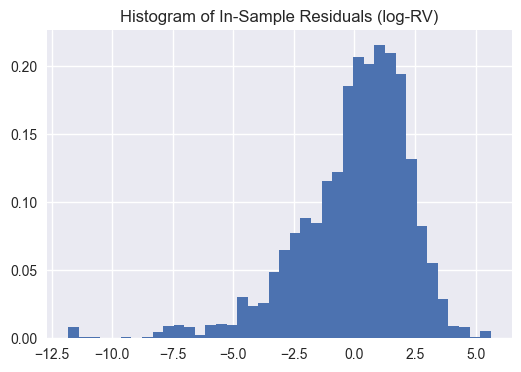


Saved HAR-RV forecasts to: ../data/processed/har_forecasts.csv


In [ ]:
# ===========================================
# Notebook 04 — HAR-RV Volatility Baseline
# ===========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os

plt.style.use("seaborn-v0_8")

# Load Data
rv_path = "../data/processed/realized_vol.csv"

df = pd.read_csv(rv_path, parse_dates=["Date"]).set_index("Date")

# Choose Daily-Base RV Series for HAR
df["RV"] = df["RV_daily_sq"] 

# Construct HAR 
'''
HAR-RV model (modeled on log(RV) to stabilize variance):
RV_t = β0 + β_d * RV_{t-1} + β_w * RV_{t-1:t-5 avg} + β_m * RV_{t-1:t-22 avg} + ε_t
'''
df["RV_d"] = df["RV"].shift(1)                      
df["RV_w"] = df["RV"].rolling(5).mean().shift(1)    
df["RV_m"] = df["RV"].rolling(22).mean().shift(1)  

# Log-transform to stabilize
eps = 1e-8
df["y_log"]     = np.log(df["RV"]   + eps)
df["RV_d_log"]  = np.log(df["RV_d"] + eps)
df["RV_w_log"]  = np.log(df["RV_w"] + eps)
df["RV_m_log"]  = np.log(df["RV_m"] + eps)

har_df = df[["y_log", "RV_d_log", "RV_w_log", "RV_m_log"]].dropna()

# Train/Test Split (80% training - 20% testing)
split_idx = int(len(har_df) * 0.80)
train = har_df.iloc[:split_idx]
test  = har_df.iloc[split_idx:]

X_train = train[["RV_d_log", "RV_w_log", "RV_m_log"]]
y_train = train["y_log"]

X_test  = test[["RV_d_log", "RV_w_log", "RV_m_log"]]
y_test  = test["y_log"]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# Fit HAR-RV via OLS
X_train_const = sm.add_constant(X_train)
har_model = sm.OLS(y_train, X_train_const)
har_result = har_model.fit()

print("\nHAR-RV model summary:")
print(har_result.summary())

# In-Sample Fit & Out-of-Sample Forecast
# Predict log-RV, then exponentiate back to RV scale.

# In-sample
y_hat_train_log = har_result.predict(sm.add_constant(X_train))
rv_hat_train    = np.exp(y_hat_train_log)

# Out-of-sample
y_hat_test_log  = har_result.predict(sm.add_constant(X_test))
rv_hat_test     = np.exp(y_hat_test_log)

# Align indices
rv_hat_train.index = train.index
rv_hat_test.index  = test.index

# Actual RV (not log)
rv_train_actual = np.exp(train["y_log"])
rv_test_actual  = np.exp(test["y_log"])

# Plot Out-of-Sample Forecast vs Actual
'''
This plot compares the HAR models out-of-sample forecasts with the observed daily volatility.

The HAR-RV model captures the overall low-volatility environment and reacts moderately to medium-sized movements. 
However, similar to GARCH, HAR consistently underestimates large volatility spikes, especially during high-stress periods.
This is expected because HAR is a linear model built on lagged averages, which smooth out extreme events.

Still, the model tracks the general level and regime shifts better than GARCH, 
confirming HARs well-known strength as a simple but strong volatility baseline.
'''
plt.figure(figsize=(14, 6))
plt.plot(rv_test_actual.index, rv_test_actual, label="Actual RV (daily)", alpha=0.8)
plt.plot(rv_hat_test.index, rv_hat_test, label="HAR-RV Forecast", alpha=0.9)
plt.title("HAR-RV Out-of-Sample Forecast vs Actual Realized Volatility")
plt.legend()
plt.show()

# Forecast Evaluation (Test Set)
mse = ((rv_test_actual - rv_hat_test) ** 2).mean()
mae = (rv_test_actual - rv_hat_test).abs().mean()

print("\nHAR-RV Forecast Performance on Test Set:")
print(f"MSE: {mse:.6e}")
print(f"MAE: {mae:.6e}")

# Residual Diagnostics (In-Sample)
resid_in_log = y_train - y_hat_train_log

'''
This plot the residuals from the HAR regression when predicting log-realized volatility inside the training sample.

A well-specified HAR model should leave residuals that look roughly random, without clear patterns or clustering.
Hence, the residuals plot is centered around zero but still contain occasional extreme negative values, 
indicating that HAR sometimes underpredicts sharp volatility jumps.

Overall, the residuals appear stationary and mostly uncorrelated, 
supporting the adequacy of the HAR model for baseline forecasting.
'''
plt.figure(figsize=(14, 4))
plt.plot(resid_in_log.index, resid_in_log)
plt.title("HAR-RV In-Sample Residuals (log-RV)")
plt.show()

'''
This plot the histogram of the distribution of HAR residuals.

The shape is peaked around zero with noticeable heavy tails—especially on the negative side.
This reflects rare but severe volatility shocks in the VIX.
These fat tails indicate that the errors are not perfectly Gaussian, which is normal for volatility data.

Although HAR handles average volatility levels well, it struggles to fully explain extreme events, 
suggesting that nonlinear or deep-learning models might provide better tail-risk modeling.
'''
plt.figure(figsize=(6, 4))
plt.hist(resid_in_log, bins=40, density=True)
plt.title("Histogram of In-Sample Residuals (log-RV)")
plt.show()

# Save Data
os.makedirs("../data/processed", exist_ok=True)
har_output = pd.DataFrame({
    "HAR_RV_forecast": rv_hat_test,
    "RV_actual": rv_test_actual
})
har_output.index.name = "Date"
out_path = "../data/processed/har_forecasts.csv"
har_output.to_csv(out_path)
print("\nSaved HAR-RV forecasts to:", out_path)